# LatamPulse — Análisis Exploratorio

Comparación de costo de vida y poder adquisitivo entre Argentina, Brasil, Uruguay y Colombia.

Lee directamente de `data/processed/` (generado por `run_pipeline.py`) — no necesita que Postgres esté corriendo para explorar los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

PROCESSED_DIR = "../data/processed"

prices = pd.read_csv(f"{PROCESSED_DIR}/prices.csv")
ppp_factors = pd.read_csv(f"{PROCESSED_DIR}/ppp_factors.csv")
exchange_rates = pd.read_csv(f"{PROCESSED_DIR}/exchange_rates.csv")
inflation = pd.read_csv(f"{PROCESSED_DIR}/inflation_indices.csv")
inflation["period"] = pd.to_datetime(inflation["period"])

print(f"prices: {len(prices)} filas")
print(f"ppp_factors: {len(ppp_factors)} filas")
print(f"exchange_rates: {len(exchange_rates)} filas")
print(f"inflation_indices: {len(inflation)} filas")

prices: 47 filas
ppp_factors: 4 filas
exchange_rates: 7 filas
inflation_indices: 6459 filas


## 1. Precios comparables entre países

No todos los 52 ítems del research manual están en los 4 países (algunos quedaron pendientes de investigar). Esta sección filtra a los ítems que sí tenemos en 2 o más países, para que la comparación sea justa.

In [2]:
items_por_pais = prices.groupby("item_name")["country"].nunique()
items_comparables = items_por_pais[items_por_pais >= 2].index.tolist()

print(f"Ítems presentes en 2+ países: {len(items_comparables)} de {items_por_pais.shape[0]} totales")
print()
for item in items_comparables:
    paises = prices[prices["item_name"] == item]["country"].tolist()
    print(f"  - {item}: {sorted(paises)}")

Ítems presentes en 2+ países: 11 de 13 totales

  - Alquiler 1 ambiente, zona céntrica (mensual): ['AR', 'BR', 'CO', 'UY']
  - Alquiler 2 ambientes, zona no céntrica (mensual): ['AR', 'BR', 'CO', 'UY']
  - Boleto transporte público urbano, tarifa base: ['AR', 'BR', 'CO', 'UY']
  - Café con leche/cortado, en cafetería: ['AR', 'BR', 'CO', 'UY']
  - Cerveza nacional 0.5L, en bar/restaurante: ['AR', 'BR', 'CO', 'UY']
  - Entrada de cine (1 persona, horario normal): ['AR', 'BR', 'CO', 'UY']
  - Gimnasio, membresía mensual: ['AR', 'BR', 'BR', 'CO', 'CO', 'UY']
  - Menú/plato principal, restaurante gama media (1 persona): ['AR', 'BR', 'CO', 'UY']
  - Prepaga/plan de salud privado, plan básico individual (mensual): ['AR', 'BR']
  - Spotify Individual (mensual): ['AR', 'BR', 'CO', 'UY']
  - Viaje corto en app (Uber/Cabify/99/DiDi), ~5km urbano: ['AR', 'AR', 'BR', 'CO', 'UY']


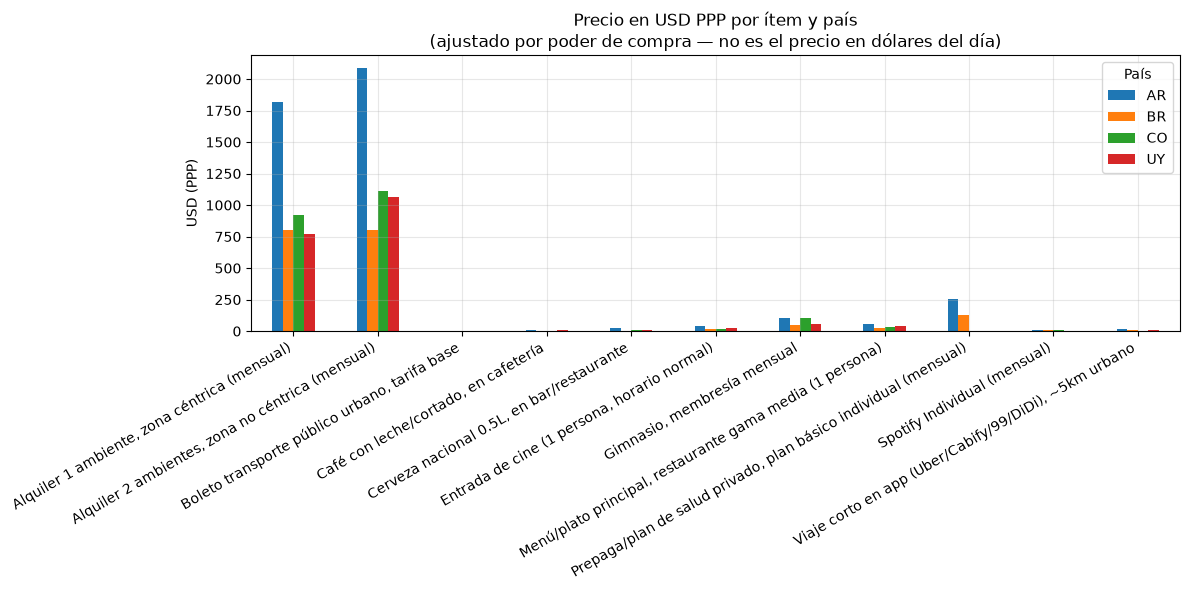

In [3]:
comparables_df = prices[prices["item_name"].isin(items_comparables)]

pivot_ppp = comparables_df.pivot_table(
    index="item_name", columns="country", values="price_usd_ppp", aggfunc="first"
)

pivot_ppp.plot(kind="bar", figsize=(12, 6))
plt.title("Precio en USD PPP por ítem y país\n(ajustado por poder de compra — no es el precio en dólares del día)")
plt.ylabel("USD (PPP)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.legend(title="País")
plt.tight_layout()
plt.show()

## 2. USD nominal vs USD PPP — por qué importa la diferencia

**Gap conocido:** solo tenemos tipo de cambio nominal extraído para Argentina (dolarapi). Para Brasil/Uruguay/Colombia, `price_usd_nominal` está vacío — así que esta comparación específica solo se puede hacer con los datos de Argentina por ahora.

La brecha entre nominal y PPP para Argentina es la historia central del proyecto: el dólar oficial argentino está subvaluado respecto al poder de compra real, así que el precio "en dólares de verdad" (PPP) da sistemáticamente más alto que el nominal.

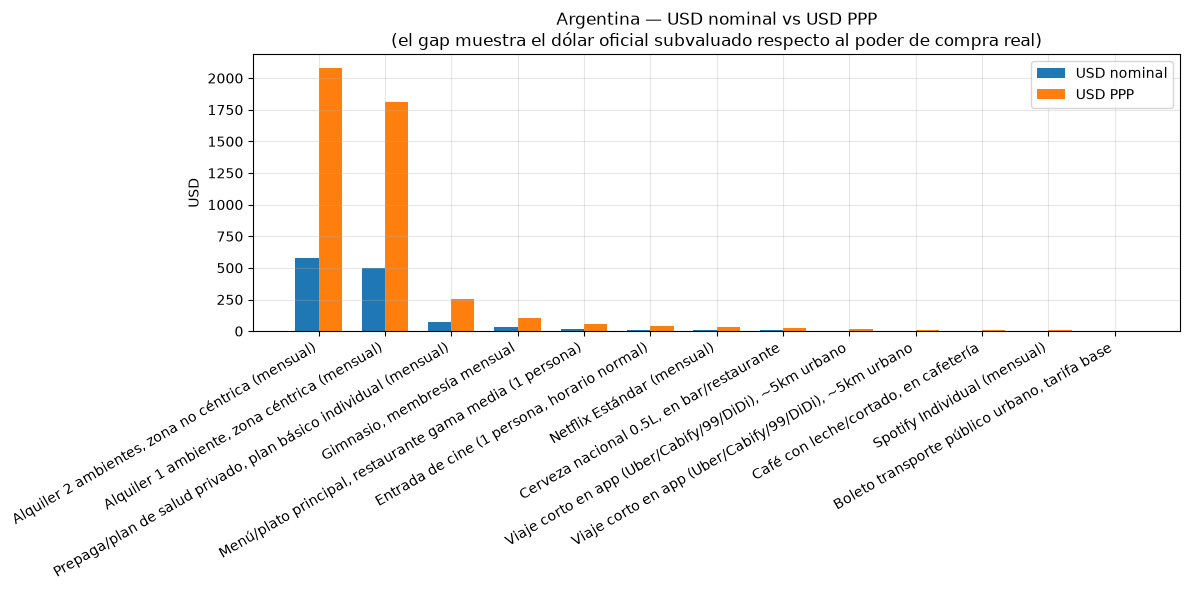

In [4]:
ar_con_nominal = prices[(prices["country"] == "AR") & (prices["price_usd_nominal"].notna())].copy()

if ar_con_nominal.empty:
    print("No hay filas de Argentina con USD nominal calculado todavía.")
else:
    ar_con_nominal = ar_con_nominal.sort_values("price_usd_ppp", ascending=False)

    x = range(len(ar_con_nominal))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar([i - width/2 for i in x], ar_con_nominal["price_usd_nominal"], width, label="USD nominal")
    ax.bar([i + width/2 for i in x], ar_con_nominal["price_usd_ppp"], width, label="USD PPP")
    ax.set_xticks(list(x))
    ax.set_xticklabels(ar_con_nominal["item_name"], rotation=30, ha="right")
    ax.set_ylabel("USD")
    ax.set_title("Argentina — USD nominal vs USD PPP\n(el gap muestra el dólar oficial subvaluado respecto al poder de compra real)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Inflación mensual comparada

**Problema de fondo resuelto acá:** las 4 fuentes NO reportan lo mismo.
- Brasil (IBGE) da variación mensual en % directo.
- Colombia (DANE) y Uruguay (INE) dan el nivel del índice, no la variación — hay que calcularla.
- Argentina (INDEC) tiene ambas, usamos la variación mensual del Nivel General ya calculada.

Al calcular variación mensual desde el nivel del índice, si hay un mes faltante en la serie (pasa en Uruguay), el cálculo salta sobre el hueco y da un número que en realidad es de 2+ meses, no 1 — eso se **detecta y descarta**, no se muestra como si fuera mensual real.

In [5]:
INDICATOR_MAP = {
    "BR": {"name": "ipca_variacao_mensal", "type": "direct_pct"},
    "AR": {"name": "indec_0_variacion_mensual", "type": "direct_pct"},
    "CO": {"name": "ipc_indice", "type": "level"},
    "UY": {"name": "ipc_indice", "type": "level"},
}

def compute_monthly_pct(country_code, config, df):
    ind_name, ind_type = config["name"], config["type"]
    sub = df[(df["country_code"] == country_code) & (df["indicator"] == ind_name)].copy()
    sub = sub.sort_values("period").reset_index(drop=True)

    if ind_type == "direct_pct":
        return sub[["country_code", "period", "value"]].dropna()

    # type == "level": calculamos % de variación desde el nivel del índice
    sub["value"] = sub["value"].pct_change() * 100

    # Detección de huecos: si el mes anterior en la serie no es el mes
    # calendario inmediatamente previo, el % calculado no es una
    # variación mensual real — se descarta en vez de mostrarse como tal.
    period_m = sub["period"].dt.to_period("M").astype("int64")
    gap = period_m.diff()
    sub.loc[gap != 1, "value"] = pd.NA

    return sub[["country_code", "period", "value"]].dropna()

series = [compute_monthly_pct(c, cfg, inflation) for c, cfg in INDICATOR_MAP.items()]
unified_inflation = pd.concat(series, ignore_index=True)

print("Filas por país en la serie unificada:")
print(unified_inflation.groupby("country_code").size())

Filas por país en la serie unificada:
country_code
AR    114
BR     24
CO    281
UY    173
dtype: int64


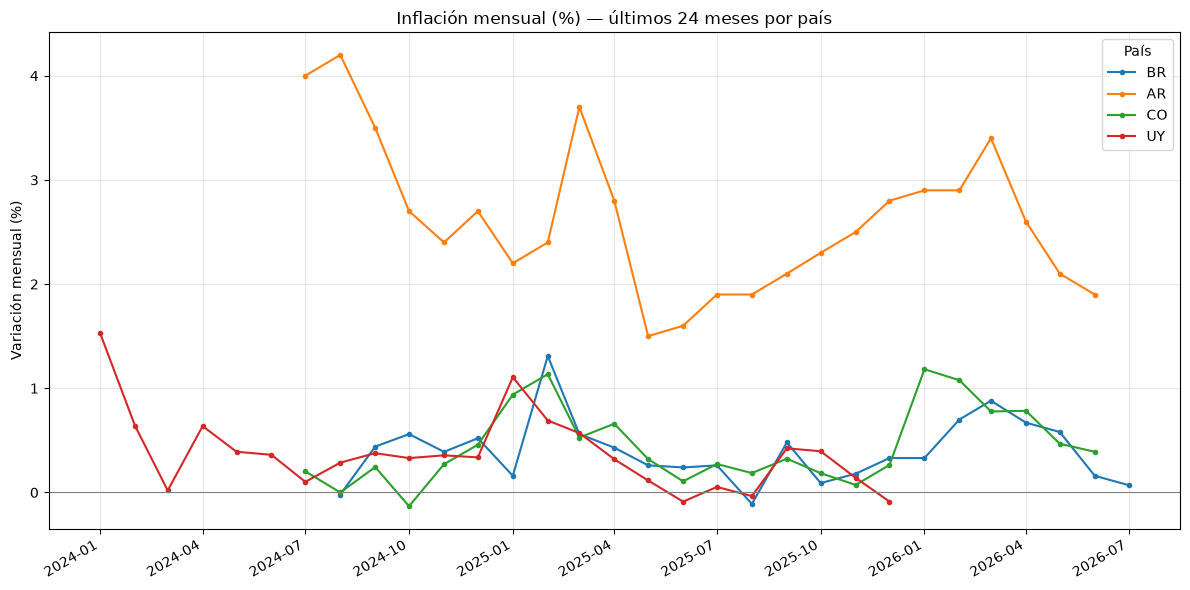

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for country in unified_inflation["country_code"].unique():
    sub = unified_inflation[unified_inflation["country_code"] == country].sort_values("period")
    # Últimos 24 meses para que el gráfico no quede saturado
    sub = sub.tail(24)
    ax.plot(sub["period"], sub["value"], marker="o", markersize=3, label=country)

ax.set_title("Inflación mensual (%) — últimos 24 meses por país")
ax.set_ylabel("Variación mensual (%)")
ax.set_xlabel("")
ax.legend(title="País")
ax.axhline(0, color="gray", linewidth=0.8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Poder adquisitivo — GDP per cápita PPP

De World Bank. Da una foto macro de qué tan lejos está cada país en términos de poder de compra promedio — contexto para interpretar los gráficos anteriores.

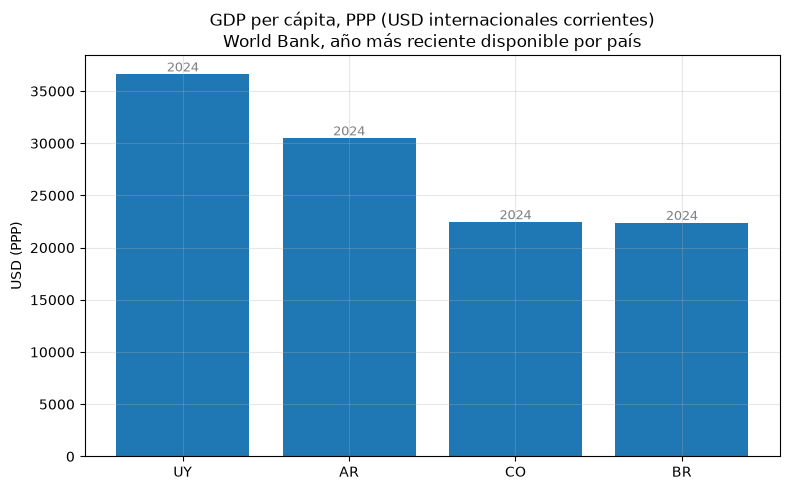

In [7]:
ppp_sorted = ppp_factors.sort_values("gdp_per_capita_ppp_current", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ppp_sorted["country_code"], ppp_sorted["gdp_per_capita_ppp_current"])
ax.set_title("GDP per cápita, PPP (USD internacionales corrientes)\nWorld Bank, año más reciente disponible por país")
ax.set_ylabel("USD (PPP)")

for bar, year in zip(bars, ppp_sorted["year"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(year)}",
            ha="center", va="bottom", fontsize=9, color="gray")

plt.tight_layout()
plt.show()

## Próximos pasos

- Completar los ítems del research manual que faltan (ver `AGENTS.md` para la lista).
- Extraer tipo de cambio nominal para Brasil/Uruguay/Colombia — hoy solo Argentina tiene esa comparación completa (nominal vs PPP).
- Con más ítems comparables, expandir la Sección 1 a un heatmap o ranking por categoría.